# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_ind
from numpy.random import seed
medical = pd.read_csv('data/insurance2.csv')

In [4]:
medical.shape

(1338, 8)

In [5]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__ The histogram of charges is strongly right-skewed, with a long upper tail and a few very large values. The sample mean is 13,270.42 and the sample standard deviation is 12,110.01. These are still useful summaries, especially because the sample size is large, but they do not describe the shape of the distribution especially well because the data are not symmetric and the mean/standard deviation are sensitive to outliers.

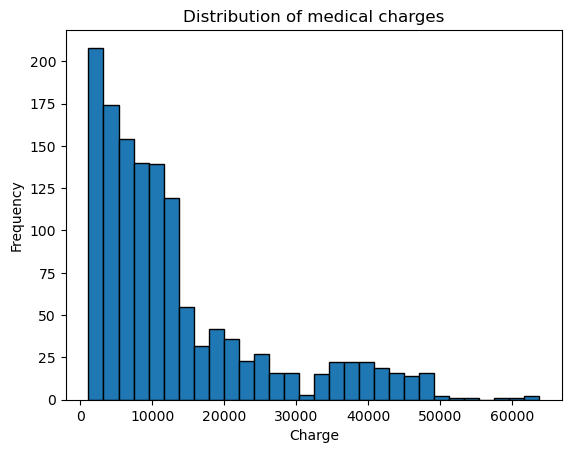

In [6]:
charges = medical['charges']

plt.hist(charges, bins=30, edgecolor='black')
plt.xlabel('Charge')
plt.ylabel('Frequency')
plt.title('Distribution of medical charges')
plt.show()

In [7]:
mean_charge = charges.mean()
std_charge = charges.std(ddof=1)

print(f"Mean charge: {mean_charge:.2f}")
print(f"Sample standard deviation: {std_charge:.2f}")


Mean charge: 13270.42
Sample standard deviation: 12110.01


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

 If we treat these observations as a random sample from the hospital's patient charges, then the sample mean can be used to make inference about the population mean charge. Even though the raw distribution of charges is skewed, the sample size is large (n = 1338), so by the Central Limit Theorem the sampling distribution of the sample mean will be approximately normal. Because the population standard deviation is unknown and we estimate it from the sample, the most appropriate frequentist test is a one-sample t-test for the mean.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ The question is directional, so a one-sided interval is appropriate. Using the sample mean and sample standard deviation, the standard error is 331.07 and the one-sided 95% critical value is t* = 1.646 with 1337 degrees of freedom. A 95% one-sided lower confidence interval for the mean is [12,725.82, ∞). Because the entire interval lies above 12,000, the administrator should not be concerned that the true mean charge has fallen below the threshold.

In [8]:
n = len(charges)
sample_mean = charges.mean()
sample_std = charges.std(ddof=1)
standard_error = sample_std / np.sqrt(n)

print(f"n = {n}")
print(f"Sample mean = {sample_mean:.2f}")
print(f"Sample standard deviation = {sample_std:.2f}")
print(f"Standard error = {standard_error:.2f}")

n = 1338
Sample mean = 13270.42
Sample standard deviation = 12110.01
Standard error = 331.07


In [9]:
df = n - 1
t_crit = t.ppf(0.95, df=df)   # one-sided 95% critical value

print(f"Degrees of freedom = {df}")
print(f"One-sided 95% critical value = {t_crit:.6f}")

Degrees of freedom = 1337
One-sided 95% critical value = 1.645994


In [10]:
lower_bound = sample_mean - t_crit * standard_error

print(f"95% one-sided lower confidence interval for the mean: [{lower_bound:.2f}, inf)")

95% one-sided lower confidence interval for the mean: [12725.49, inf)


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ Let group 0 be patients without an insurance claim and group 1 be patients with an insurance claim. Then the null hypothesis is $H_0: \mu_0 = \mu_1$ and the alternative is $H_A: \mu_0 \ne \mu_1$.
. This is a two-sample t-test for independent samples. Because the pooled standard deviation formula is used, we are assuming the two population variances are equal (homoscedasticity), in addition to assuming the two samples are independent random samples.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ Manually, the pooled standard deviation is 11,520.03 and the test statistic is t = -11.8933 for 1336 degrees of freedom, giving a two-sided p-value of approximately 4.46 × 10^-31. Using scipy.stats.ttest_ind(..., equal_var=True) gives the same result up to numerical precision.

In [11]:
no_claim = medical[medical['insuranceclaim'] == 0]['charges']
claim = medical[medical['insuranceclaim'] == 1]['charges']

n0, n1 = len(no_claim), len(claim)
mean0, mean1 = no_claim.mean(), claim.mean()
std0, std1 = no_claim.std(ddof=1), claim.std(ddof=1)

print(f"Group 0 (no claim): n={n0}, mean={mean0:.2f}, sd={std0:.2f}")
print(f"Group 1 (claim):    n={n1}, mean={mean1:.2f}, sd={std1:.2f}")

Group 0 (no claim): n=555, mean=8821.42, sd=6446.51
Group 1 (claim):    n=783, mean=16423.93, sd=14045.93


In [12]:
sp = np.sqrt(((n0 - 1) * std0**2 + (n1 - 1) * std1**2) / (n0 + n1 - 2))
t_stat = (mean0 - mean1) / (sp * np.sqrt(1/n0 + 1/n1))
df = n0 + n1 - 2

print(f"Pooled standard deviation = {sp:.6f}")
print(f"t statistic = {t_stat:.6f}")
print(f"Degrees of freedom = {df}")

Pooled standard deviation = 11520.034269
t statistic = -11.893299
Degrees of freedom = 1336


In [13]:
p_value = 2 * t.cdf(t_stat, df=df)   # because t_stat is negative

print(f"Two-sided p-value (manual) = {p_value:.6e}")

Two-sided p-value (manual) = 4.461230e-31


In [16]:
scipy_result = ttest_ind(no_claim, claim, equal_var=True)
scipy_result

TtestResult(statistic=np.float64(-11.893299030876712), pvalue=np.float64(4.461230231620717e-31), df=np.float64(1336.0))

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ I did not see a direct one-sample z-test for a mean in scipy.stats analogous to the one-sample t-test. In practice, when the population standard deviation is unknown, the t-test is the standard method, which is why SciPy focuses on it. If you truly wanted a z-test, you would usually compute the z-statistic manually and use the normal distribution (scipy.stats.norm) to get a p-value or confidence interval. 

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test